# Single Moving Average Strategy Backtest

**What this notebook does:**

Tests Moving Average trading strategy on historical stock data:
- **BUY** (go long) when the stock price is **above** its moving average
- **GO TO CASH/SHORT** when the stock price is **below** its moving average

It then compares: did this strategy beat just holding the stock?

The second part brute-forces every MA length from 10 to 500 to find which lookback period would have performed best historically.


## Setup & Imports

4 Libraries
- `numpy` — fast math on arrays
- `yfinance` — free historical price data from Yahoo Finance
- `matplotlib` — plotting / charting
- `pandas` — DataFrames (spreadsheet-like tables for data manipulation)

In [2]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

## Configuration

Change these variables to test different assets or MA lengths:
- `TICKER` — which asset to backtest
- `WINDOW` — the moving average lookback period in trading days (300 days ≈ ~14 months)

In [3]:
TICKER = 'ES=F'
WINDOW = 300

## Step 1: Download Price Data & Calculate the Moving Average

Downloads the full price history from Yahoo Finance (since 1993) and computes the simple moving average (SMA).

**How `.rolling(n).mean()` works:** it creates a sliding window of `n` days and takes the average of each window. The first `(n - 1)` rows will be `NaN` because there aren't enough data points yet to fill the window.

In [4]:
def get_data():
    df = yf.download(TICKER, start="1993-01-01")
    df.columns = df.columns.get_level_values(0)  # flatten multi-level column headers

    df['MA'] = df['Close'].rolling(WINDOW).mean()  # simple moving average of closing price
    return df

## Step 2: Generate Trading Signals

The rule:
- If today's Close **>** today's MA → signal = `1` (go long tomorrow)
- If today's Close **≤** today's MA → signal = `0` (go to cash tomorrow)

We can use `0` (cash) and `-1` (short). That means when price is below the MA, we can simply step aside or bet against the market. `0` & `-1` are changeable. 

### `.shift(1)` matters

**This is the most important line in any backtest.** It moves the signal forward by one day, simulating the fact that you can only *act* on today's signal *tomorrow* (you see the close, then enter the trade the next day). Without this shift, you'd be using future information — a classic backtest mistake called **look-ahead bias**.

In [5]:
def add_strategy(df):
    df['Strategy'] = np.where(df['Close'] > df['MA'], 1, 0)  # 1 = long, 0 = cash
    df['Strategy'] = df['Strategy'].shift(1)                  # shift to avoid look-ahead bias
    return df

## Step 3: Calculate & Compare Returns

Computes cumulative returns for both buy-and-hold and the MA strategy, then plots them.

**The math, step by step:**
1. `pct_change()` — calculates daily percentage change (e.g., 100 → 102 = +2%)
2. `1 + daily_return` — converts to a growth factor (e.g., +2% becomes 1.02)
3. `cumprod()` — multiplies all growth factors together cumulatively
4. `- 1` — converts back to percentage terms

For the strategy returns, we multiply daily returns by the Strategy signal. On days where Strategy = 0 (cash), the return contribution is zero — we effectively "turn off" returns when we're out of the market.

In [6]:
def test_strategy(df):
    df['asset_cumulative'] = np.cumprod(1 + df['Close'].pct_change().fillna(0)) - 1
    df['strategy_cumulative'] = np.cumprod(1 + (df['Close'].pct_change() * df['Strategy']).fillna(0)) - 1

    df = df.iloc[-10000:, :]  # keep last 10,000 rows for plotting

    plt.plot(df['asset_cumulative'])
    plt.plot(df['strategy_cumulative'])
    plt.legend([f'{TICKER} Cumulative Returns', f'{WINDOW} Moving Average Cumulative Returns'])
    plt.show()
    return df

## Step 4: Run the Backtest

[*********************100%***********************]  1 of 1 completed


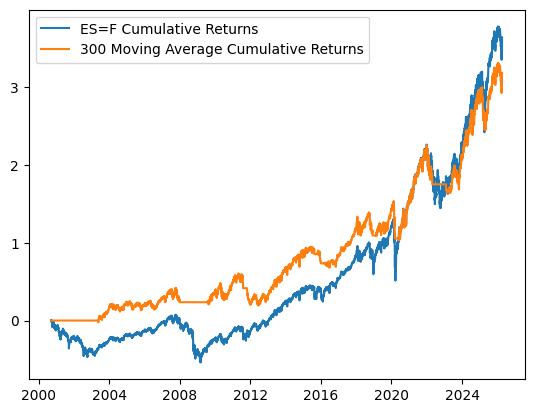

Price,Close,High,Low,Open,Volume,MA,Strategy,asset_cumulative,strategy_cumulative
Date,,,,,,,,,
2000-09-18,1467.50,1489.75,1462.25,1485.25,104794,NaN,NaN,0.000000,0.000000
2000-09-19,1478.50,1482.75,1466.75,1467.00,103371,NaN,0.0,0.007496,0.000000
2000-09-20,1469.50,1480.50,1450.25,1478.75,109667,NaN,0.0,0.001363,0.000000
2000-09-21,1469.50,1474.00,1455.50,1470.25,98528,NaN,0.0,0.001363,0.000000
2000-09-22,1468.50,1471.00,1436.75,1454.75,97416,NaN,0.0,0.000681,0.000000
...,...,...,...,...,...,...,...,...,...
2026-04-01,6617.75,6653.75,6561.00,6562.00,1752607,6377.785666,1.0,3.509540,3.066001
2026-04-02,6622.25,6644.50,6503.75,6618.50,1965184,6379.353166,1.0,3.512606,3.068766
2026-04-06,6651.00,6661.00,6567.00,6590.00,1103916,6381.078999,1.0,3.532198,3.086430


In [7]:
def main():
    df = get_data()
    df = add_strategy(df)
    df = test_strategy(df)
    return df

main()

---

Find the Best MA Window (Grid Search)

Tests every moving average window from 10 to 500 (in steps of 10) and ranks them by final cumulative return.





In [8]:
def find_best_window():
    results = []

    df_raw = yf.download(TICKER, start="1993-01-01")       # ← moved out of the loop
    df_raw.columns = df_raw.columns.get_level_values(0)

    for window in range(10, 501, 10):
        df = df_raw.copy()                                  # ← reuse a fresh copy

        df['MA'] = df['Close'].rolling(window).mean()
        df['Strategy'] = np.where(df['Close'] > df['MA'], 1, 0)
        df['Strategy'] = df['Strategy'].shift(1)

        returns = df['Close'].pct_change()
        strategy_returns = (returns * df['Strategy']).fillna(0)
        cumulative = (1 + strategy_returns).cumprod() - 1

        final_return = cumulative.iloc[-1]
        results.append((window, final_return))

    results.sort(key=lambda x: x[1], reverse=True)
    return results

results = find_best_window()

for r in results[:10]:
    print(r)

[*********************100%***********************]  1 of 1 completed

(320, np.float64(3.8790446558554548))
(330, np.float64(3.6121775866456733))
(400, np.float64(3.5521855560258118))
(220, np.float64(3.5094281869238424))
(230, np.float64(3.445007927556743))
(410, np.float64(3.3790944246990087))
(340, np.float64(3.375435907243917))
(390, np.float64(3.325097696044624))
(310, np.float64(3.3237776081913726))
(360, np.float64(3.250074799816012))
